In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as psnr

# Konfigurasi plot agar hasil terlihat jelas
plt.rcParams['figure.figsize'] = [15, 8]

noise

In [18]:
def add_salt_pepper_noise(image, prob):
    """
    Menambahkan noise Salt & Pepper pada citra untuk simulasi Task 1.
    """
    output = np.copy(image)
    
    # Mode Salt (Putih)
    num_salt = np.ceil(prob * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    output[tuple(coords)] = 255

    # Mode Pepper (Hitam)
    num_pepper = np.ceil(prob * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    output[tuple(coords)] = 0
    return output

def calculate_mse(img1, img2):
    """
    Menghitung Mean Squared Error (MSE) untuk analisis kuantitatif.
    """
    h, w = img1.shape
    diff = cv2.subtract(img1, img2)
    err = np.sum(diff**2)
    mse = err / (float(h * w))
    return mse

filter

In [ ]:
# Path folder dataset kamu
folder_path = 'images/padi'  # Ganti dengan path folder gambarmu
files = os.listdir(folder_path)[:20] # Ambil 20 gambar

results = []

for idx, file in enumerate(files):
    img_path = os.path.join(folder_path, file)
    
    # Baca gambar dalam Grayscale agar lebih mudah dianalisis filternya
    img_original = cv2.imread(img_path, 0) 
    if img_original is None: continue

    #  Task 1: Implementasi preprocessing citra ber-noise 
    # Kita tambahkan noise buatan agar bisa di-filter
    img_noisy = add_salt_pepper_noise(img_original, prob=0.05)

    #  Task 3: Implementasi minimal 3 jenis filter 
    # Filter 1: Average Blur (Kernel 5x5)
    img_blur = cv2.blur(img_noisy, (5,5))
    
    # Filter 2: Gaussian Blur (Kernel 5x5)
    img_gauss = cv2.GaussianBlur(img_noisy, (5,5), 0)
    
    # Filter 3: Median Blur (Kernel 5) -> Biasanya terbaik untuk Salt & Pepper
    img_median = cv2.medianBlur(img_noisy, 5)

    # Simpan hasil sementara untuk visualisasi nanti
    results.append({
        'filename': file,
        'original': img_original,
        'noisy': img_noisy,
        'blur': img_blur,
        'gaussian': img_gauss,
        'median': img_median
    })

print(f"Berhasil memproses {len(results)} gambar.")

Berhasil memproses 20 gambar.


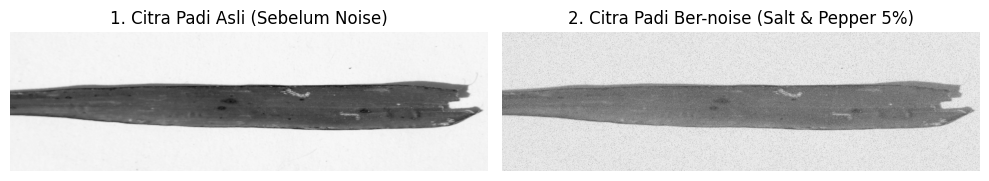

In [20]:
# Mengambil sampel pertama dari hasil list
sample = results[0] 

# Mengatur ukuran figur plot
plt.figure(figsize=(10, 5))

# Plot 1: Citra Padi Asli
plt.subplot(1, 2, 1)
plt.imshow(sample['original'], cmap='gray')
plt.title('1. Citra Padi Asli (Sebelum Noise)')
plt.axis('off')

# Plot 2: Citra Padi Ber-noise
plt.subplot(1, 2, 2)
plt.imshow(sample['noisy'], cmap='gray')
plt.title('2. Citra Padi Ber-noise (Salt & Pepper 5%)')
plt.axis('off')

# Menampilkan plot
plt.tight_layout()
plt.show()

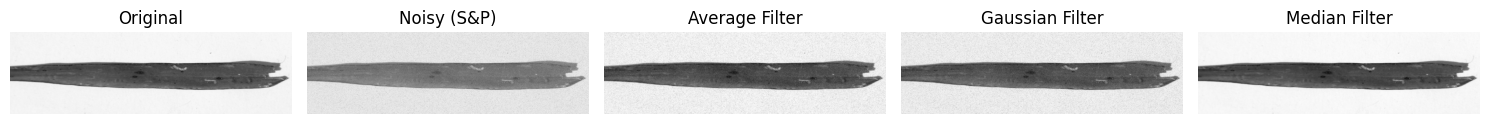

--- Analisis Komparatif Kualitas Citra (Sampel: DSC_0293.JPG) ---
| Metode Filter    | MSE (Lower is Better) | PSNR (Higher is Better) |
|------------------|-----------------------|-------------------------|
| Average Filter   | 30.90                 | 29.67 dB                |
| Gaussian Filter  | 30.75                 | 27.73 dB                |
| Median Filter    | 0.55                 | 47.03 dB                |


In [ ]:
# Ambil contoh 1 gambar untuk ditampilkan detail visualnya
sample = results[0] 

titles = ['Original', 'Noisy (S&P)', 'Average Filter', 'Gaussian Filter', 'Median Filter']
images = [sample['original'], sample['noisy'], sample['blur'], sample['gaussian'], sample['median']]

plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

#  Task 4: Analisis Komparatif (Kuantitatif) 
print(f" Analisis Komparatif Kualitas Citra (Sampel: {sample['filename']}) ")
print("| Metode Filter    | MSE (Lower is Better) | PSNR (Higher is Better) |")
print("||--|-|")

for i, key in enumerate(['blur', 'gaussian', 'median']):
    mse_val = calculate_mse(sample['original'], sample[key])
    psnr_val = psnr(sample['original'], sample[key])
    print(f"| {titles[i+2]:<16} | {mse_val:.2f}                 | {psnr_val:.2f} dB                |")

visualisasi

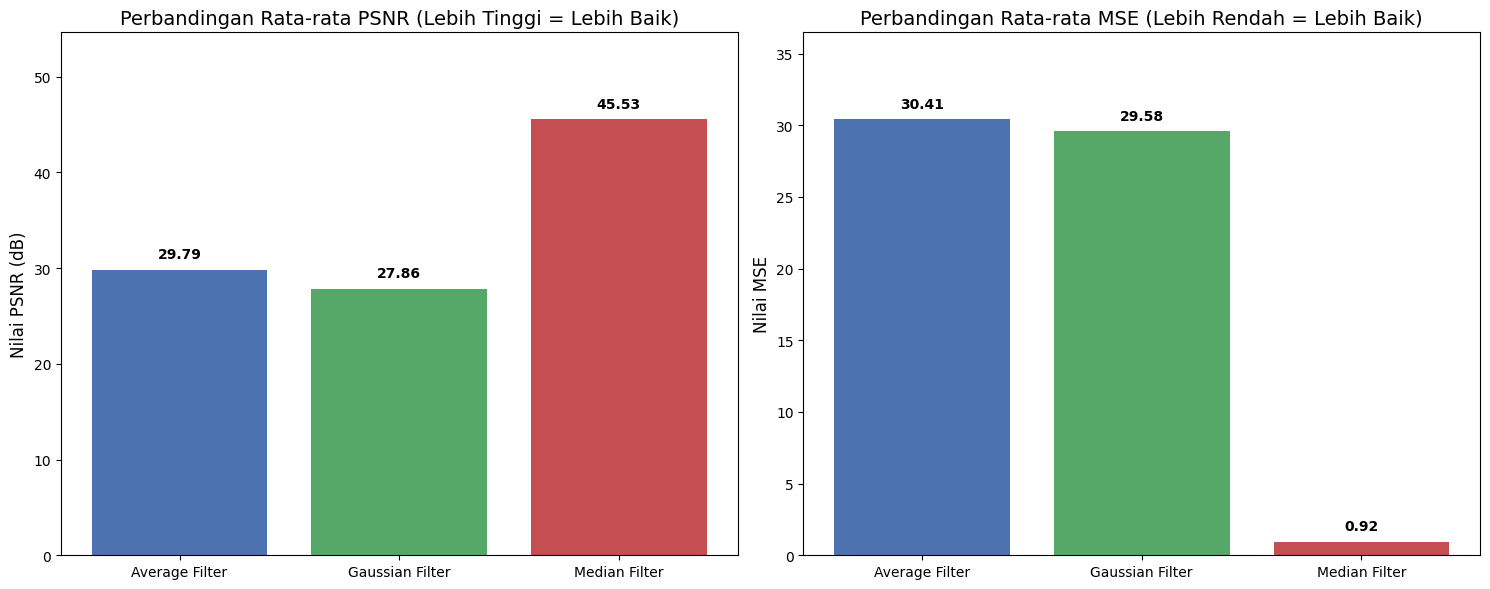

In [ ]:
# Siapkan list untuk menyimpan nilai metrik dari 20 gambar
psnr_blur, psnr_gaussian, psnr_median = [], [], []
mse_blur, mse_gaussian, mse_median = [], [], []

# Hitung metrik untuk semua gambar yang ada di list 'results'
for data in results:
    original = data['original']
    
    # Kumpulkan nilai PSNR
    psnr_blur.append(psnr(original, data['blur']))
    psnr_gaussian.append(psnr(original, data['gaussian']))
    psnr_median.append(psnr(original, data['median']))
    
    # Kumpulkan nilai MSE
    mse_blur.append(calculate_mse(original, data['blur']))
    mse_gaussian.append(calculate_mse(original, data['gaussian']))
    mse_median.append(calculate_mse(original, data['median']))

# Menghitung rata-rata metrik dari seluruh dataset
avg_psnr = [np.mean(psnr_blur), np.mean(psnr_gaussian), np.mean(psnr_median)]
avg_mse = [np.mean(mse_blur), np.mean(mse_gaussian), np.mean(mse_median)]
filters = ['Average Filter', 'Gaussian Filter', 'Median Filter']

# Membuat visualisasi Bar Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

#  Plot 1: Rata-rata PSNR 
bars1 = ax1.bar(filters, avg_psnr, color=['#4C72B0', '#55A868', '#C44E52'])
ax1.set_title('Perbandingan Rata-rata PSNR (Lebih Tinggi = Lebih Baik)', fontsize=14)
ax1.set_ylabel('Nilai PSNR (dB)', fontsize=12)
ax1.set_ylim(0, max(avg_psnr) * 1.2)

# Tambahkan label angka di atas setiap batang (Plot 1)
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + (max(avg_psnr) * 0.02), f'{yval:.2f}', 
             ha='center', va='bottom', fontweight='bold')

#  Plot 2: Rata-rata MSE 
bars2 = ax2.bar(filters, avg_mse, color=['#4C72B0', '#55A868', '#C44E52'])
ax2.set_title('Perbandingan Rata-rata MSE (Lebih Rendah = Lebih Baik)', fontsize=14)
ax2.set_ylabel('Nilai MSE', fontsize=12)
ax2.set_ylim(0, max(avg_mse) * 1.2)

# Tambahkan label angka di atas setiap batang (Plot 2) - PERBAIKAN DI SINI
for bar in bars2:
    yval = bar.get_height()
    # Menggunakan offset dinamis (2% dari nilai max) agar selalu pas di dalam kotak
    offset = max(avg_mse) * 0.02 
    ax2.text(bar.get_x() + bar.get_width()/2, yval + offset, f'{yval:.2f}', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

simpan semua gambar

In [ ]:
# import os
# import cv2

# # Buat folder output jika belum ada
# output_dir = 'hasil_filtering_padi'
# if not os.path.exists(output_dir):
#     os.makedirs(output_dir)

# print(f"Memulai proses penyimpanan gambar ke folder: {output_dir}/")

# # Loop untuk menyimpan semua hasil dari dataset
# for data in results:
#     filename = data['filename']
#     name, ext = os.path.splitext(filename)
    
#     # Simpan masing-masing versi citra
#     cv2.imwrite(os.path.join(output_dir, f"{name}_noisy{ext}"), data['noisy'])
#     cv2.imwrite(os.path.join(output_dir, f"{name}_blur{ext}"), data['blur'])
#     cv2.imwrite(os.path.join(output_dir, f"{name}_gaussian{ext}"), data['gaussian'])
#     cv2.imwrite(os.path.join(output_dir, f"{name}_median{ext}"), data['median'])

# print("Semua gambar berhasil disimpan!")

# #  TAMBAHAN UNTUK PENGGUNA GOOGLE COLAB 
# # Jika kamu menjalankan .ipynb ini di Google Colab, jalankan baris di bawah ini 
# # (hapus tanda pagar/komentar) untuk membuat file .zip agar mudah didownload:

# # !zip -r hasil_filtering_padi.zip hasil_filtering_padi/
# # from google.colab import files
# # files.download('hasil_filtering_padi.zip')